In [104]:
import pandas as pd

In [105]:
sales_df = pd.read_csv('C:/Users/venuk/trading-projects/sales-forecast-system/data/sales.csv')

In [106]:
sales_df.dtypes

Order time    str
Net sales     str
dtype: object

In [107]:
sales_df.head(10)

,Order time,Net sales
0,01/08/2026,945.76
1,31/07/2026,666.98
2,30/07/2026,571.16
3,29/07/2026,513.37
4,28/07/2026,546.14
5,27/07/2026,347.7
6,26/07/2026,449.53
7,25/07/2026,640.32
8,24/07/2026,637.55
9,23/07/2026,670.12


In [108]:
pd.to_numeric(sales_df['Order time'], errors='coerce').isna().sum()

np.int64(264)

In [109]:
sales_df.shape

(264, 2)

In [110]:
sales_df['Order time'] = pd.to_datetime(sales_df['Order time'], format='%d/%m/%Y')

In [111]:
sales_df['Net sales'] = sales_df['Net sales'].str.replace(',', '').astype(float)

In [112]:
sales_df.dtypes

Order time    datetime64[us]
Net sales            float64
dtype: object

In [113]:
sales_df.head(10)


,Order time,Net sales
0,2026-08-01,945.76
1,2026-07-31,666.98
2,2026-07-30,571.16
3,2026-07-29,513.37
4,2026-07-28,546.14
5,2026-07-27,347.70
6,2026-07-26,449.53
7,2026-07-25,640.32
8,2026-07-24,637.55
9,2026-07-23,670.12


In [114]:
sales_df['Date'] = sales_df['Order time']

In [115]:
sales_df = sales_df.drop(columns = ['Order time'])

In [116]:
sales_df.shape

(264, 2)

In [117]:
import matplotlib.pyplot as plt

In [118]:
sales_df.dtypes

Net sales           float64
Date         datetime64[us]
dtype: object

Text(0, 0.5, 'Net sales')

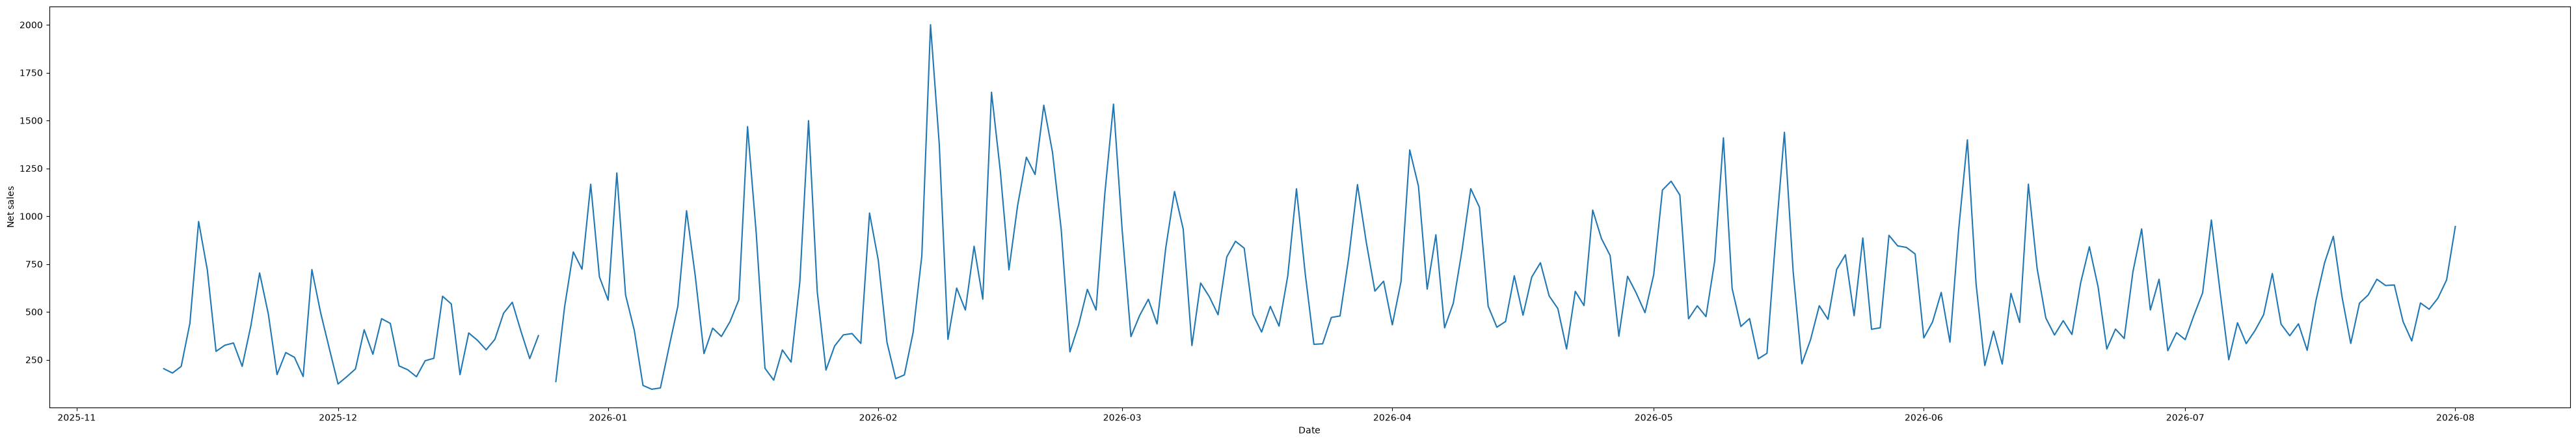

In [119]:
plt.figure(figsize=(50,8))
plt.plot(sales_df['Date'], sales_df['Net sales'])
plt.xlabel('Date')
plt.ylabel('Net sales')

In [120]:
sales_df.head(10)

,Net sales,Date
0,945.76,2026-08-01
1,666.98,2026-07-31
2,571.16,2026-07-30
3,513.37,2026-07-29
4,546.14,2026-07-28
5,347.70,2026-07-27
6,449.53,2026-07-26
7,640.32,2026-07-25
8,637.55,2026-07-24
9,670.12,2026-07-23


In [121]:
from statsmodels.tsa.stattools import adfuller

In [122]:
pd.to_numeric(sales_df['Net sales'], errors='coerce').isna().sum()

np.int64(1)

In [123]:
sales_df.head(264)


,Net sales,Date
0,945.76,2026-08-01
1,666.98,2026-07-31
2,571.16,2026-07-30
3,513.37,2026-07-29
4,546.14,2026-07-28
...,...,...
259,971.99,2025-11-15
260,440.32,2025-11-14
261,214.85,2025-11-13
262,180.11,2025-11-12


In [124]:
sales_df[sales_df['Net sales'].isna()]

,Net sales,Date
219,NaN,2025-12-25


In [125]:
sales_df = sales_df.drop(index=219)

In [126]:
sales_df['Net sales'].isna().sum()

np.int64(0)

In [127]:
result = adfuller(sales_df['Net sales'])

In [128]:
print('ADF statistic: ', result[0])
print('P value: ', result[1])

ADF statistic:  -2.2745237668701064
P value:  0.18031623852428946


In [129]:
sales_df['diff1'] = sales_df['Net sales'].diff()

In [130]:
sales_df['diff17'] = sales_df['diff1'].diff(7)

Text(0.5, 1.0, 'Raw series')

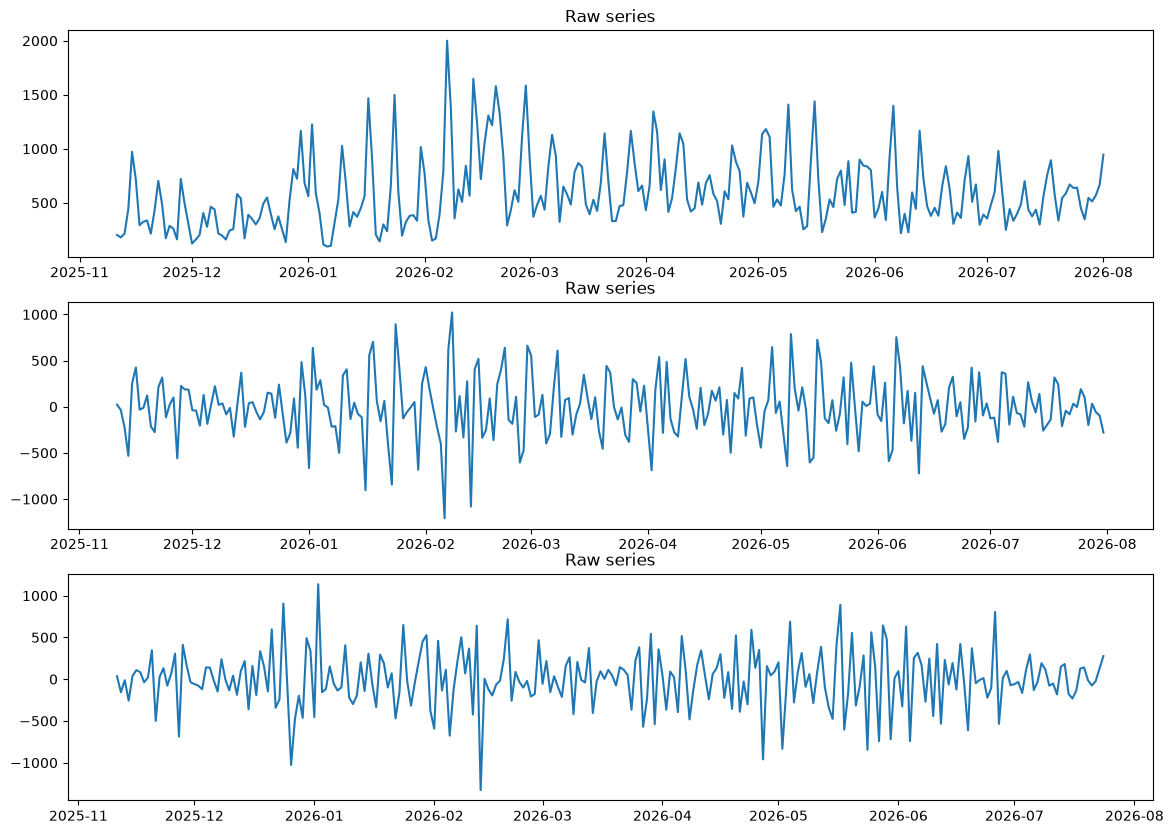

In [133]:
fig, axes = plt.subplots(3,1, figsize=(14, 10))

axes[0].plot(sales_df['Date'], sales_df['Net sales'])
axes[0].set_title('Raw series')

axes[1].plot(sales_df['Date'], sales_df['diff1'])
axes[1].set_title('Raw series')

axes[2].plot(sales_df['Date'], sales_df['diff17'])
axes[2].set_title('Raw series')

In [135]:
diff_result = adfuller(sales_df['diff17'].dropna())

In [136]:
print('ADF stat:', diff_result[0])
print('P value:', diff_result[1])

ADF stat: -6.600305025707838
P value: 6.7620430361183055e-09


In [137]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
fig, axes = (2, 1, figsize= (14, 8))

plot_acf(sales_df['diff17'].dropna(), lags=30, ax=axes[0])
axes[0].set_title('ACF')

plot_pacf(sales_df['diff17'].dropna(), lags=30, ax=axes[1])
axes[1].set_title('PACF')


SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (3277578064.py, line 1)